In [108]:
import math
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [109]:
print(os.getcwd())

C:\Users\Cheng\OneDrive\Documents\Github\VarianceArithmetic\IPyNb


In [110]:
df = pd.read_csv("../Cpp/Output/AdjMatrix_4_12.txt", sep='	')
df.head()

,Type,Noise,Size,Count,Adj Unc Deviation,Adj Unc Mean,Adj Unc Minimum,Adj Unc Maximum,Adj Unc Count,Adj Unc Loss,...,1.2,1.4,1.6,1.8,2,2.2,2.4,2.6,2.8,3
0,Gaussian,0.000000e+00,4,625,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,10000,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Gaussian,1.000000e-17,4,625,4.734054e-11,1.318343e-10,6.037227e-12,3.618041e-10,10000,0,...,0.001507,0.000904,0.000402,0.000804,0.000603,0.000301,0.001005,0.000502,0.001005,0.000201
2,Gaussian,1.000000e-16,4,625,4.858082e-10,1.309832e-09,4.961377e-11,3.510975e-09,10000,0,...,0.044524,0.036984,0.024350,0.021396,0.018441,0.014162,0.010087,0.007539,0.004890,0.001630
3,Gaussian,1.000000e-15,4,625,4.658131e-09,1.260086e-08,8.074551e-10,3.375186e-08,10000,0,...,0.044346,0.030501,0.021371,0.016153,0.008829,0.006923,0.004816,0.002207,0.002107,0.000602
4,Gaussian,1.000000e-14,4,625,4.724813e-08,1.306333e-07,9.064066e-09,3.592223e-07,10000,0,...,0.038604,0.029780,0.017146,0.017748,0.009927,0.007420,0.003209,0.002106,0.001404,0.000501


In [111]:
df.columns

Index(['Type', 'Noise', 'Size', 'Count', 'Adj Unc Deviation', 'Adj Unc Mean',
       'Adj Unc Minimum', 'Adj Unc Maximum', 'Adj Unc Count', 'Adj Unc Loss',
       'Adj Val Deviation', 'Adj Val Mean', 'Adj Val Minimum',
       'Adj Val Maximum', 'Adj Val Count', 'Adj Val Loss',
       'Adj Norm Deviation', 'Adj Norm Mean', 'Adj Norm Minimum',
       'Adj Norm Maximum', 'Adj Norm Count', 'Adj Norm Loss',
       'Fwd Unc Deviation', 'Fwd Unc Mean', 'Fwd Unc Minimum',
       'Fwd Unc Maximum', 'Fwd Unc Count', 'Fwd Unc Loss', 'Fwd Val Deviation',
       'Fwd Val Mean', 'Fwd Val Minimum', 'Fwd Val Maximum', 'Fwd Val Count',
       'Fwd Val Loss', 'Fwd Norm Deviation', 'Fwd Norm Mean',
       'Fwd Norm Minimum', 'Fwd Norm Maximum', 'Fwd Norm Count',
       'Fwd Norm Loss', 'Rnd Unc Deviation', 'Rnd Unc Mean', 'Rnd Unc Minimum',
       'Rnd Unc Maximum', 'Rnd Unc Count', 'Rnd Unc Loss', 'Rnd Val Deviation',
       'Rnd Val Mean', 'Rnd Val Minimum', 'Rnd Val Maximum', 'Rnd Val Count',
       '

In [112]:
df['Noise'].unique()

array([0.e+00, 1.e-17, 1.e-16, 1.e-15, 1.e-14, 1.e-13, 1.e-12, 1.e-11,
       1.e-10, 1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03,
       1.e-02, 1.e-01, 1.e+00, 1.e+01])

In [113]:
df[df['Noise'] == 0][['Size', 'Adj Norm Mean', 'Fwd Norm Mean', 'Rnd Norm Mean']].head()

,Size,Adj Norm Mean,Fwd Norm Mean,Rnd Norm Mean
0,4,NaN,NaN,NaN
20,5,NaN,NaN,NaN
40,6,NaN,NaN,NaN
60,7,NaN,NaN,NaN
80,8,NaN,NaN,NaN


# Overall

In [114]:
def PlotSurface(value, title='', zlabel='', logz=False, zlim=[], cmap=None, view=(30, 45)):
    dfOrderVsNoise = df[(df['Noise']>0)]                .pivot(index='Noise', columns='Size', values=value)
    sOrder = dfOrderVsNoise.columns.values
    sNoise = dfOrderVsNoise.index.values
    sX, sY = np.meshgrid(sOrder, sNoise)
    sY = np.log10(sY)
    sZ = np.log10(dfOrderVsNoise.values) if logz else dfOrderVsNoise.values

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(*view)
    surf = ax.plot_surface( sX, sY, sZ, cmap=cmap if cmap else plt.cm.spring if logz else plt.cm.winter )
    cb = fig.colorbar(surf, shrink=0.5, aspect=5, pad=0.15)

    if title:
        ax.set_title(title)
    else:
        ax.set_title(f'{value}')

    ax.set_xlabel('Size')
    sXTick = [sOrder[i] for i in range(0, len(sOrder), 1)]
    ax.set_xticks(sXTick, [f'{x}' for x in sXTick])

    ax.set_ylabel('Input Noise')
    sYTick = [sNoise[i] for i in range(0, len(sNoise), 3)]
    ax.set_yticks(np.log10(sYTick), [f'{y:.1e}' for y in sYTick])

    if zlabel:
        ax.set_zlabel(zlabel)
    else:
        ax.set_zlabel(value)
    if logz:
        zMin = int(math.floor(np.min(sZ)))
        zMax = int(math.ceil(np.max(sZ)))
        step = max(1, int(math.ceil((zMax - zMin)/10)))
        sZTick = range(zMin, zMax, step)
        ax.set_zticks(sZTick, [f'1e{z:+}' for z in sZTick])
    elif zlim:
        ax.set_zlim(zlim)


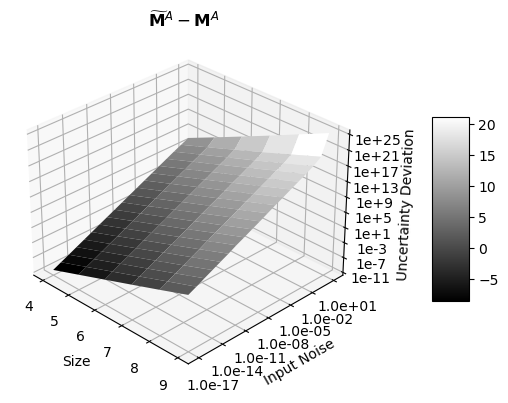

In [115]:
PlotSurface('Adj Unc Deviation', logz=True, cmap=plt.cm.gray, view=(30, -45),
            title=r'$\widetilde{\mathbf{M}}^A - \mathbf{M}^A$', zlabel='Uncertainty Deviation')

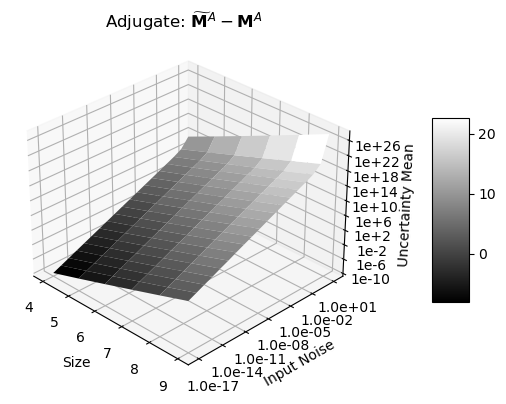

In [116]:
PlotSurface('Adj Unc Mean', logz=True, cmap=plt.cm.gray, view=(30, -45),
            title=r'Adjugate: $\widetilde{\mathbf{M}}^A - \mathbf{M}^A$', zlabel='Uncertainty Mean')

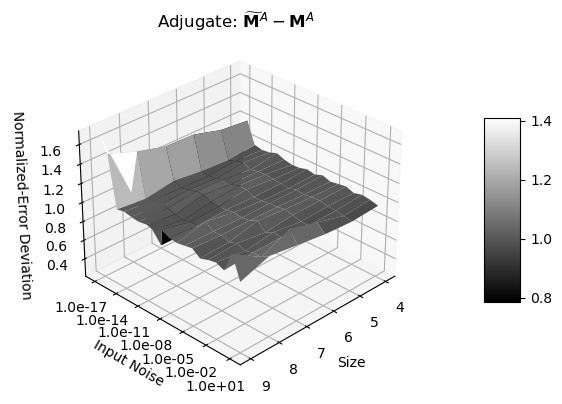

In [117]:
PlotSurface('Adj Norm Deviation', cmap=plt.cm.gray, 
            title=r'Adjugate: $\widetilde{\mathbf{M}}^A - \mathbf{M}^A$', zlabel='Normalized-Error Deviation')

In [118]:
df[df['Noise'] > 10e-14]['Adj Norm Deviation'].mean(), df[df['Noise'] > 10e-16]['Adj Norm Deviation'].std()

(1.0009761816405276, 0.031650032717176105)

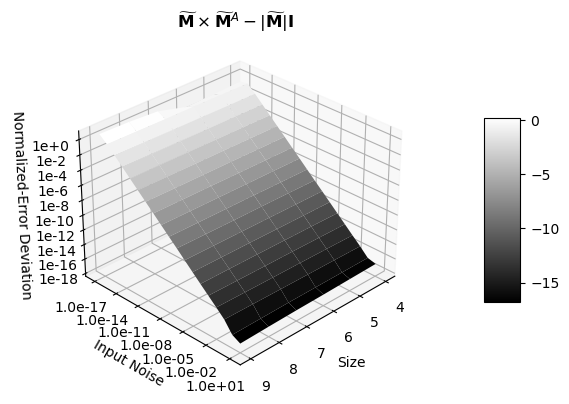

In [119]:
PlotSurface('Fwd Norm Deviation', cmap=plt.cm.gray, logz=True,
            title=r'$\widetilde{\mathbf{M}} \times \widetilde{\mathbf{M}}^A - |\widetilde{\mathbf{M}}| \mathbf{I}$',
            zlabel='Normalized-Error Deviation')

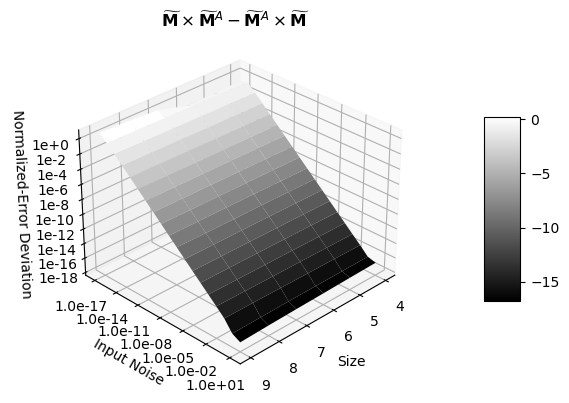

In [120]:
PlotSurface('Rnd Norm Deviation', cmap=plt.cm.gray, logz=True,
            title=r'$\widetilde{\mathbf{M}} \times \widetilde{\mathbf{M}}^A - \widetilde{\mathbf{M}}^A \times \widetilde{\mathbf{M}}$',
            zlabel='Normalized-Error Deviation')

# Normalized Error Histogram

Per-row probability of the Adj normalized error `(adj_noisy − adj_precise) / σ_pred`
falling into each 0.2-wide bin from −3 to +3 (31 bins). Out-of-range samples are
dropped. A faithful Formula (6.9) predictor should produce a roughly standard-
Normal-shaped curve at every noise level above the rounding floor.

In [121]:
sHisto = [f'{i/10:g}' for i in range(-30, 32, 2)]
df['Label'] = df['Size'].astype(str) + ' ' + df['Noise'].astype(str)

<AxesSubplot:title={'center':'Adjugate Normalized Error (Size 8)'}, xlabel='Normalized Error', ylabel='Normalized Count'>

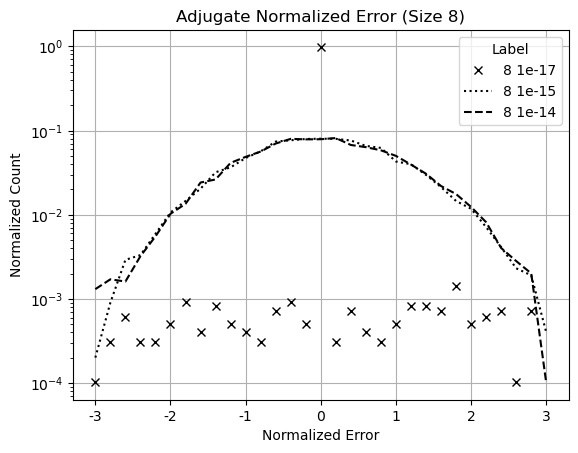

In [127]:
dfHisto = df[(df['Noise'].isin([1e-17, 1e-16, 1e-15, 1e-14])) & (df['Size'] == 8)].set_index('Label')
dfHisto[sHisto].T.plot(grid=True, title=r'Adjugate Normalized Error (Size 8)',
                       style=['kx','k:','k--','k-'], logy=True,
                       xlabel='Normalized Error', ylabel='Normalized Count')

<AxesSubplot:title={'center':'Adjugate Normalized Error (Size 10)'}, xlabel='Normalized Error', ylabel='Normalized Count'>

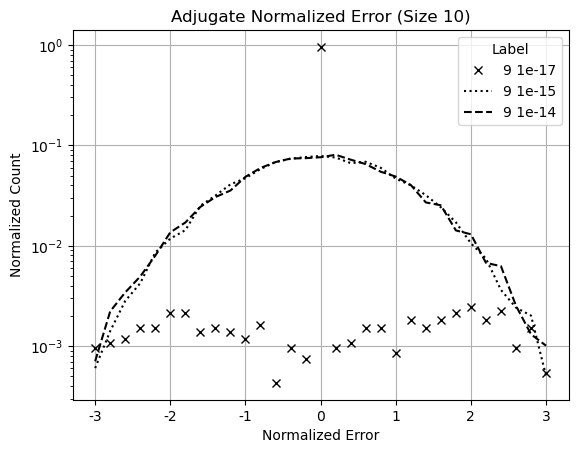

In [128]:
dfHisto = df[(df['Noise'].isin([1e-17, 1e-16, 1e-15, 1e-14])) & (df['Size'] == 9)].set_index('Label')
dfHisto[sHisto].T.plot(grid=True, title=r'Adjugate Normalized Error (Size 10)',
                       style=['kx','k:','k--','k-'], logy=True,
                       xlabel='Normalized Error', ylabel='Normalized Count')

<AxesSubplot:title={'center':'Adjugate Normalized Error (Noise = 1e-16)'}, xlabel='Normalized Error', ylabel='Normalized Count'>

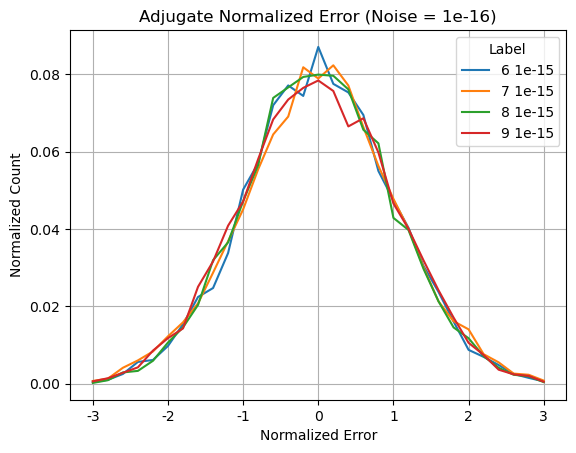

In [129]:
dfHisto = df[(df['Noise'] == 1e-15) & (df['Size'] > 5)].set_index('Label')
dfHisto[sHisto].T.plot(grid=True, title=r'Adjugate Normalized Error (Noise = 1e-16)',
                       xlabel='Normalized Error', ylabel='Normalized Count')

<AxesSubplot:title={'center':'Adjugate Normalized Error (Noise = 1e-11)'}, xlabel='Normalized Error', ylabel='Normalized Count'>

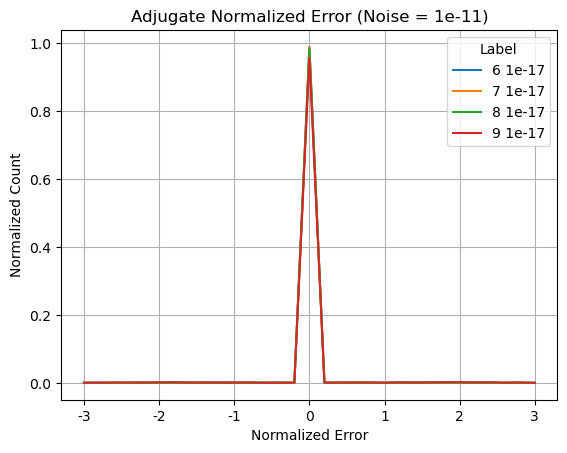

In [130]:
dfHisto = df[(df['Noise'] == 1e-17) & (df['Size'] > 5)].set_index('Label')
dfHisto[sHisto].T.plot(grid=True, title=r'Adjugate Normalized Error (Noise = 1e-11)',
                       xlabel='Normalized Error', ylabel='Normalized Count')

<AxesSubplot:title={'center':'Adjugate Normalized Error (Noise = 1.0)'}, xlabel='Normalized Error', ylabel='Normalized Count'>

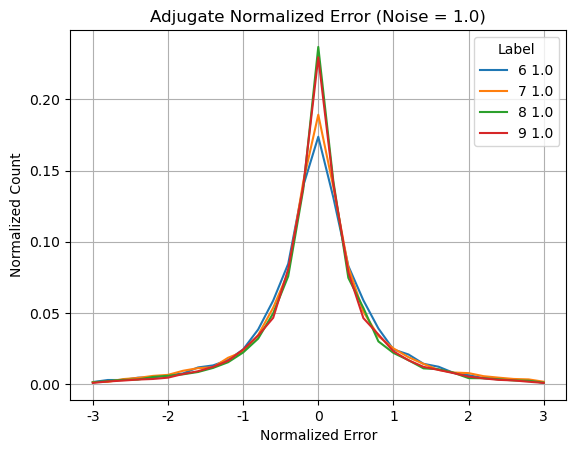

In [131]:
dfHisto = df[(df['Noise'] == 1) & (df['Size'] > 5)].set_index('Label')
dfHisto[sHisto].T.plot(grid=True, title=r'Adjugate Normalized Error (Noise = 1.0)',
                       xlabel='Normalized Error', ylabel='Normalized Count')

# log(Fwd Norm Deviation) vs log(Noise) by Size

Linear fit of log10(Fwd Norm Deviation) against log10(Noise) for each matrix Size,
restricted to Noise > 1e-17 (drops zero-input and sub-ulp-floor rows). The slope
is the power-law exponent: Fwd Norm Deviation ~ Noise^slope.

In [ ]:
from scipy.stats import linregress

df_fwd = df[df['Noise'] > 1e-17]

regression = []
for size, group in df_fwd.groupby('Size'):
    g = group[group['Fwd Norm Deviation'] > 0]
    if len(g) < 3: continue
    log_noise = np.log10(g['Noise'])
    log_fed   = np.log10(g['Fwd Norm Deviation'])
    res = linregress(log_noise, log_fed)
    regression.append({
        'Size': size,
        'Slope': res.slope,
        'Intercept': res.intercept,
        'R2': res.rvalue ** 2,
        'p-value': res.pvalue,
        'StdErr (slope)': res.stderr,
        'N': len(g),
    })

reg_df = pd.DataFrame(regression).set_index('Size')
reg_df

## Across-Size Summary

In [ ]:
unweighted_mean = reg_df['Slope'].mean()
unweighted_std  = reg_df['Slope'].std(ddof=1)

weights         = 1.0 / reg_df['StdErr (slope)'] ** 2
weighted_mean   = (reg_df['Slope'] * weights).sum() / weights.sum()
combined_stderr = np.sqrt(1.0 / weights.sum())
weighted_pop_std = np.sqrt(
    (weights * (reg_df['Slope'] - weighted_mean) ** 2).sum() / weights.sum())

pd.Series({
    'Unweighted mean':          unweighted_mean,
    'Unweighted std (sample)':  unweighted_std,
    'Weighted mean':            weighted_mean,
    'Combined stderr':          combined_stderr,
    'Weighted population std':  weighted_pop_std,
})